In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference
# from SPD_solver import solve_spd
from fractal_SG_solver_new import  build_fractal_second_derivative, d2_fractal_phi_pointwise, d2_fractal_psi, d2_fractal_L_W2 
from SG_solver import d2_phi, varphi, error_function 
from fractal_SG_solver_new import ddphi, H5_dd
from alpha_fractal_function import alpha_fractalize_second_derivative

In [2]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 8
s = 0.8
c = 0.027 
################
h = 0.01
tau = 0.005
################
T = 1
###################
def exact_u(x, t):
    return 0.5 * (np.sin(np.pi * (x + t)) + np.sin(np.pi * (x - t)))

In [3]:
n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)

In [4]:
# f_alpha = [-0.0002, 0, -0.0001, -0.0001, 0, -0.0002] # with n_iter = 2 given the best result till now. 
# f_alpha = [0.0002, 0, -0.001, 0, 0, -0.001, 0, 0.0002]
f_alpha = 0
n_subintervals = 6 # len(f_alpha)
n_iter = 2
X = np.linspace(a, b, n_subintervals + 1)
Y = np.sin(X)
fractal_dd = alpha_fractalize_second_derivative(ddphi, H5_dd, -2, 2, n_subintervals, f_alpha, n_iter)

In [5]:
# Storage for time and space levels
# U[d, i] ≈ u(x_i, d*tau), d=0,...,Nt

# U = np.zeros((Nt + 2, len(x)))
f_U = np.zeros((Nt + 2, len(x)))
# print(np.shape(U), np.shape(f_U))

# Initial condition at t=0
# U[0, :] = np.sin(np.pi * x)  # exact_u(x, 0)
f_U[0, :] = np.sin(np.pi * x)

# Boundary conditions at x=a and x=b
# U[0, 0]  = 0.0
# U[0, -1] = 0.0
f_U[0, 0]  = 0.0
f_U[0, -1] = 0.0

In [6]:
# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
rhs0 = []
for kj in k_idx:
    rhs0.append(second_divided_difference(x, f_U[0, :], kj))
rhs0 = np.asarray(rhs0)

alpha0 = np.linalg.solve(A0, rhs0)

In [7]:
# for 1st time step
# uxx0 = np.zeros(len(x))
f_uxx0 = np.zeros(len(x))
for i in range(len(x)):
    # uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
    f_uxx0[i] = d2_fractal_L_W2(i, x, f_U[0, :], xk, alpha0, s, fractal_dd)
   
# Since g(x)=0
# U[1, :] = U[0, :] + 0.5 * tau**2 * uxx0
# U[1, 0]  = 0.0
# U[1, -1] = 0.0
f_U[1, :] = f_U[0, :] + 0.5 * tau**2 * f_uxx0
f_U[1, 0]  = 0.0
f_U[1, -1] = 0.0

In [8]:
for d in tqdm(range(1, Nt + 1), desc="Time stepping", unit="step"):
    A = rbf_matrix(xk, s)
    # rhs_d = np.asarray([second_divided_difference(x, U[d], kj) for kj in k_idx])
    # alpha1 = np.linalg.solve(A, rhs_d)
    f_rhs_d = np.asarray([second_divided_difference(x, f_U[d], kj) for kj in k_idx])
    alpha2 = np.linalg.solve(A, f_rhs_d)

    # uxx = np.zeros(len(x))
    f_uxx = np.zeros(len(x))
    for i in range( len(x)):
        # uxx[i] = d2_L_W2(i, x, U[d], xk, alpha1, s, c)
        f_uxx[i] = d2_fractal_L_W2(i, x, f_U[d], xk, alpha2, s, fractal_dd)
        # if i%10 == 0:
            # print(f"calssical uxx at time step {d}, index {i}: {uxx[i]}")
            # print(f"fractal uxx at time step {d}, index {i}: {f_uxx[i]}")

    # U[d + 1, :] = 2.0 * U[d, :] - U[d - 1, :] + tau**2 * uxx
    f_U[d + 1, :] = 2.0 * f_U[d, :] - f_U[d - 1, :] + tau**2 * f_uxx

    # Dirichlet boundary conditions
    # U[d + 1, 0] = 0.0
    # U[d + 1, -1] = 0.0
    f_U[d + 1, 0] = 0.0
    f_U[d + 1, -1] = 0.0

    # if d%5 == 0:
    #     t_u_num = U[d + 1, :]
    #     t_f_u_num = f_U[d + 1, :]
    #     print("____________________________________________________________")
    #     print(f"Difference at time step {d}: {np.max(np.abs(t_u_num - t_f_u_num))}")

Time stepping:   0%|          | 0/200 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 200/200 [05:29<00:00,  1.65s/step]


In [9]:
# Final solution and error at time T
# u_num = U[Nt + 1, :]
f_u_num = f_U[Nt + 1, :]
u_ex = exact_u(x, T)  # Exact solution at T+tau because of the central difference initialization)

# err = -(u_ex - u_num)
f_err = (f_u_num - u_ex)

# abs_err = np.abs(err)
f_abs_err = np.abs(f_err)

# Linf = np.max(abs_err)
f_Linf = np.max(f_abs_err)

# RMS = np.sqrt(np.mean(abs_err**2))
f_RMS = np.sqrt(np.mean(f_abs_err**2))

# Linf_difference = Linf - f_Linf
# RMS_difference = RMS - f_RMS
# print(u_num)

# print("Linf error =", Linf)
print("f_Linf error =", f_Linf)
# print("RMS error  =", RMS)
print("f_RMS error  =", f_RMS)
# print("Linf difference =", Linf_difference)
# print("RMS difference =", RMS_difference)

f_Linf error = 0.00014408543680421992
f_RMS error  = 8.944785969303775e-05


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


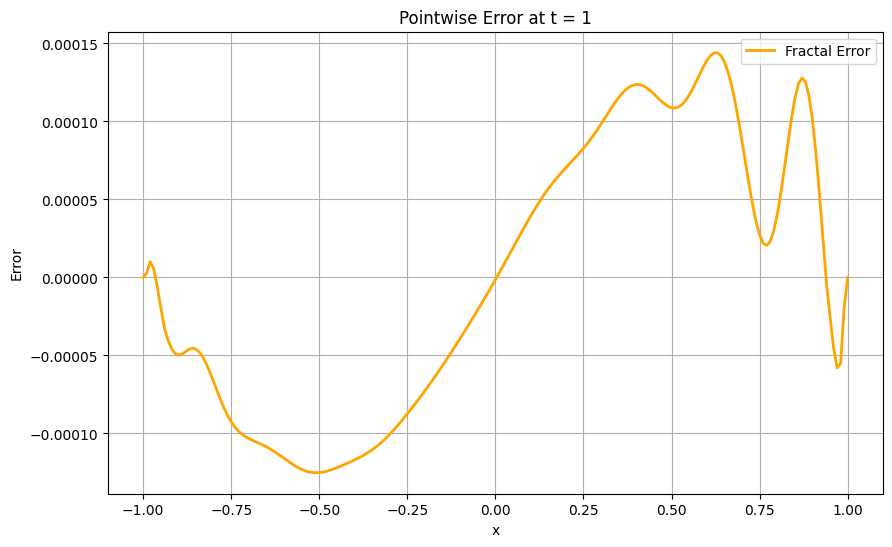

In [10]:
plt.figure(figsize=(10, 6))
# plt.plot(x, err, label="Error", color="blue", linewidth=2)
plt.plot(x, f_err, label="Fractal Error", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at t = {T}")
plt.grid(True)
plt.legend()
plt.savefig("error_plot_SG.eps", format="eps")
plt.show()